In [1]:
import pandas as pd

In [2]:
data = pd.read_excel('../data/raw/online_retail_II.xlsx', engine='openpyxl')
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


On the first sight of the data distribution we can see that we worked with `525460` data / entries and we want have to dealt with missing value on `Customer ID`

In [4]:
data.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


Next part when seeing the data description we can see that some data is missed imputed like on `Quantity: min: -9600` and `Price: min: -53594` this means we need to remove or reimpute the data.

##### Identify Nunique products `StockCode`

In [5]:
data = data[(data['Quantity'] > 0) & (data['Price'] > 0)]
data.head(1)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom


In [6]:
data.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,511566.000000,511566,511566.000000,407664.000000
mean,11.400150,2010-06-28 22:20:30.395491584,4.252563,15368.592598
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000
25%,1.000000,2010-03-21 15:22:00,1.250000,13997.000000
50%,3.000000,2010-07-07 09:41:00,2.100000,15321.000000
75%,10.000000,2010-10-15 15:06:00,4.210000,16812.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,86.761177,NaN,63.664629,1679.762138


In [7]:
data['StockCode'].nunique()

4251

In [8]:
top_51_product = (
    data.groupby('StockCode', as_index = False)
    .agg(total_quantity = ('Quantity', 'sum'))
    .sort_values('total_quantity', ascending = False)
    .head(51)
)

In [9]:
top_51_product

,StockCode,total_quantity
489,21212,60141
3796,85123A,58487
2332,84077,55091
3781,85099B,49875
50,17003,48374
2501,84879,45348
2542,84991,36502
1306,22197,32977
1120,21977,31940
506,21232,27127


So we want to pick the `Top 51 most sold products` why? because for now we dont want to forecast `4000+` products and we want to focus on the top 51 products.

In [10]:
data_top_51 = (
    data[data['StockCode'].isin(top_51_product['StockCode'])]
    .reset_index(drop = True)
)
data_top_51.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
1,489436,84879,ASSORTED COLOUR BIRD ORNAMENT,16,2009-12-01 09:06:00,1.69,13078.0,United Kingdom
2,489437,84970S,HANGING HEART ZINC T-LIGHT HOLDER,12,2009-12-01 09:08:00,0.85,15362.0,United Kingdom
3,489439,21731,RED TOADSTOOL LED NIGHT LIGHT,24,2009-12-01 09:28:00,1.65,12682.0,France
4,489442,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2009-12-01 09:46:00,2.95,13635.0,United Kingdom


In [11]:
# data_top_50.drop('index', inplace = True, axis = 1)

In [12]:
data_top_51.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41626 entries, 0 to 41625
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Invoice      41626 non-null  object        
 1   StockCode    41626 non-null  object        
 2   Description  41626 non-null  object        
 3   Quantity     41626 non-null  int64         
 4   InvoiceDate  41626 non-null  datetime64[ns]
 5   Price        41626 non-null  float64       
 6   Customer ID  34715 non-null  float64       
 7   Country      41626 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 2.5+ MB


after filtering only to get top 51 data we get around `40k+ data entries` 

In [13]:
data_top_51.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,41626.000000,41626,41626.000000,34715.000000
mean,29.302768,2010-06-29 07:05:35.142939392,1.557254,15309.733861
min,1.000000,2009-12-01 07:45:00,0.080000,12347.000000
25%,3.000000,2010-03-30 13:35:15,0.650000,13931.000000
50%,10.000000,2010-07-06 10:12:00,1.300000,15259.000000
75%,24.000000,2010-10-07 11:04:15,1.950000,16746.000000
max,19152.000000,2010-12-09 20:01:00,26.040000,18287.000000
std,197.635979,NaN,1.204690,1653.667704


In [14]:
data_top_51['StockCode'].nunique()

51

With this we can now work to the next step of Cleaning the data.

##### Cleansing

Remove missing `CustomerID`

In [15]:
data_top_51.dropna(subset=['Customer ID'], inplace=True)
data_top_51.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34715 entries, 0 to 41625
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Invoice      34715 non-null  object        
 1   StockCode    34715 non-null  object        
 2   Description  34715 non-null  object        
 3   Quantity     34715 non-null  int64         
 4   InvoiceDate  34715 non-null  datetime64[ns]
 5   Price        34715 non-null  float64       
 6   Customer ID  34715 non-null  float64       
 7   Country      34715 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 2.4+ MB


In [16]:
data_top_51.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,34715.000000,34715,34715.000000,34715.000000
mean,33.721331,2010-06-29 20:25:18.823563264,1.345365,15309.733861
min,1.000000,2009-12-01 07:45:00,0.080000,12347.000000
25%,5.000000,2010-04-01 11:48:00,0.550000,13931.000000
50%,12.000000,2010-07-06 10:42:00,1.250000,15259.000000
75%,24.000000,2010-10-05 17:55:00,1.950000,16746.000000
max,19152.000000,2010-12-09 20:01:00,3.240000,18287.000000
std,215.545321,NaN,0.799537,1653.667704


In [17]:
data_top_51.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
1,489436,84879,ASSORTED COLOUR BIRD ORNAMENT,16,2009-12-01 09:06:00,1.69,13078.0,United Kingdom
2,489437,84970S,HANGING HEART ZINC T-LIGHT HOLDER,12,2009-12-01 09:08:00,0.85,15362.0,United Kingdom
3,489439,21731,RED TOADSTOOL LED NIGHT LIGHT,24,2009-12-01 09:28:00,1.65,12682.0,France
4,489442,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2009-12-01 09:46:00,2.95,13635.0,United Kingdom


In [18]:
data_top_51['InvoiceDate'] = pd.to_datetime(data_top_51['InvoiceDate'])
data_top_51['Date'] = data_top_51['InvoiceDate'].dt.date
data_top_51.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Date
0,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-12-01
1,489436,84879,ASSORTED COLOUR BIRD ORNAMENT,16,2009-12-01 09:06:00,1.69,13078.0,United Kingdom,2009-12-01
2,489437,84970S,HANGING HEART ZINC T-LIGHT HOLDER,12,2009-12-01 09:08:00,0.85,15362.0,United Kingdom,2009-12-01
3,489439,21731,RED TOADSTOOL LED NIGHT LIGHT,24,2009-12-01 09:28:00,1.65,12682.0,France,2009-12-01
4,489442,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2009-12-01 09:46:00,2.95,13635.0,United Kingdom,2009-12-01


##### Aggregation

In [19]:
data_top_51_agg = data_top_51.groupby(['StockCode', 'Date']).agg({
    'Quantity': 'sum'
}).reset_index()

data_top_51_agg.head()

,StockCode,Date,Quantity
0,15036,2009-12-01,55
1,15036,2009-12-03,240
2,15036,2009-12-04,12
3,15036,2009-12-05,12
4,15036,2009-12-07,60


In [20]:
data_top_51_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10568 entries, 0 to 10567
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   StockCode  10568 non-null  object
 1   Date       10568 non-null  object
 2   Quantity   10568 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 247.8+ KB


After we aggregate the data into daily data, we want to fill the gaps because if a product didn't sell on a day the data would be simply be missing for that day.. Thats why we want to fill the gaps with 0 so the model could understands "zero demand".

In [21]:
# Filling Gaps
all_dates = pd.date_range(start = data_top_51_agg['Date'].min(), end = data_top_51_agg['Date'].max())
all_stocks = data_top_51_agg['StockCode'].unique()

# Multi-index and find the missing days
index = pd.MultiIndex.from_product([all_dates, all_stocks], names = ['Date', 'StockCode'])
data_top_51_daily = data_top_51_agg.set_index(['Date', 'StockCode']).reindex(index, fill_value = 0).reset_index()

data_top_51_daily.head()

,Date,StockCode,Quantity
0,2009-12-01,15036,55
1,2009-12-01,16014,0
2,2009-12-01,17003,144
3,2009-12-01,20724,110
4,2009-12-01,20725,163


# Exploratory Data Analysis (EDA)

What i want to do? Here i want to test data against different "behaviors"
- High-Volume: Products sell every day, and check the seasonality. Ex: Do sales spike every Friday? Do they dip every Monday?
- Low-Volume: Products sell once every few weeks. This so we can see if "Filling Gaps with 0 worked".
- Seasonal: With this we could see product that worked in November/December with shaped curve and near-zero sales for other months.

In [22]:
data_top_51_daily.head()

,Date,StockCode,Quantity
0,2009-12-01,15036,55
1,2009-12-01,16014,0
2,2009-12-01,17003,144
3,2009-12-01,20724,110
4,2009-12-01,20725,163


In [23]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [24]:
# top_product = data_top_51_daily[data_top_51_daily['StockCode'] == 20724]

# plt.figure(figsize = (15, 5))
# plt.plot(top_product['Date'], top_product['Quantity'])

# plt.gca().xaxis.set_major_locator(mdates.MonthLocator()) # x-axis show every month
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # Format date

# plt.xticks(rotation=45)

# plt.title('Daily Demand for StockCode 20724 ( Monthly View )')
# plt.xlabel('Date')
# plt.ylabel('Units Sold')

# plt.grid(True, alpha = 0.3)
# plt.show()

In [25]:
data_top_51_daily['StockCode'].unique()

array([15036, 16014, 17003, 20724, 20725, 20727, 21080, 21088, 21096,
       21212, 21213, 21232, 21498, 21731, 21915, 21928, 21929, 21931,
       21975, 21977, 21980, 21981, 21982, 21984, 21985, 22086, 22178,
       22197, 22355, 22386, 22411, 22492, 22952, 37410, 71459, 84077,
       84212, 84270, 84347, 84568, 84598, 84755, 84879, 84946, 84991,
       84992, '84970S', '85099B', '85099C', '85099F', '85123A'],
      dtype=object)

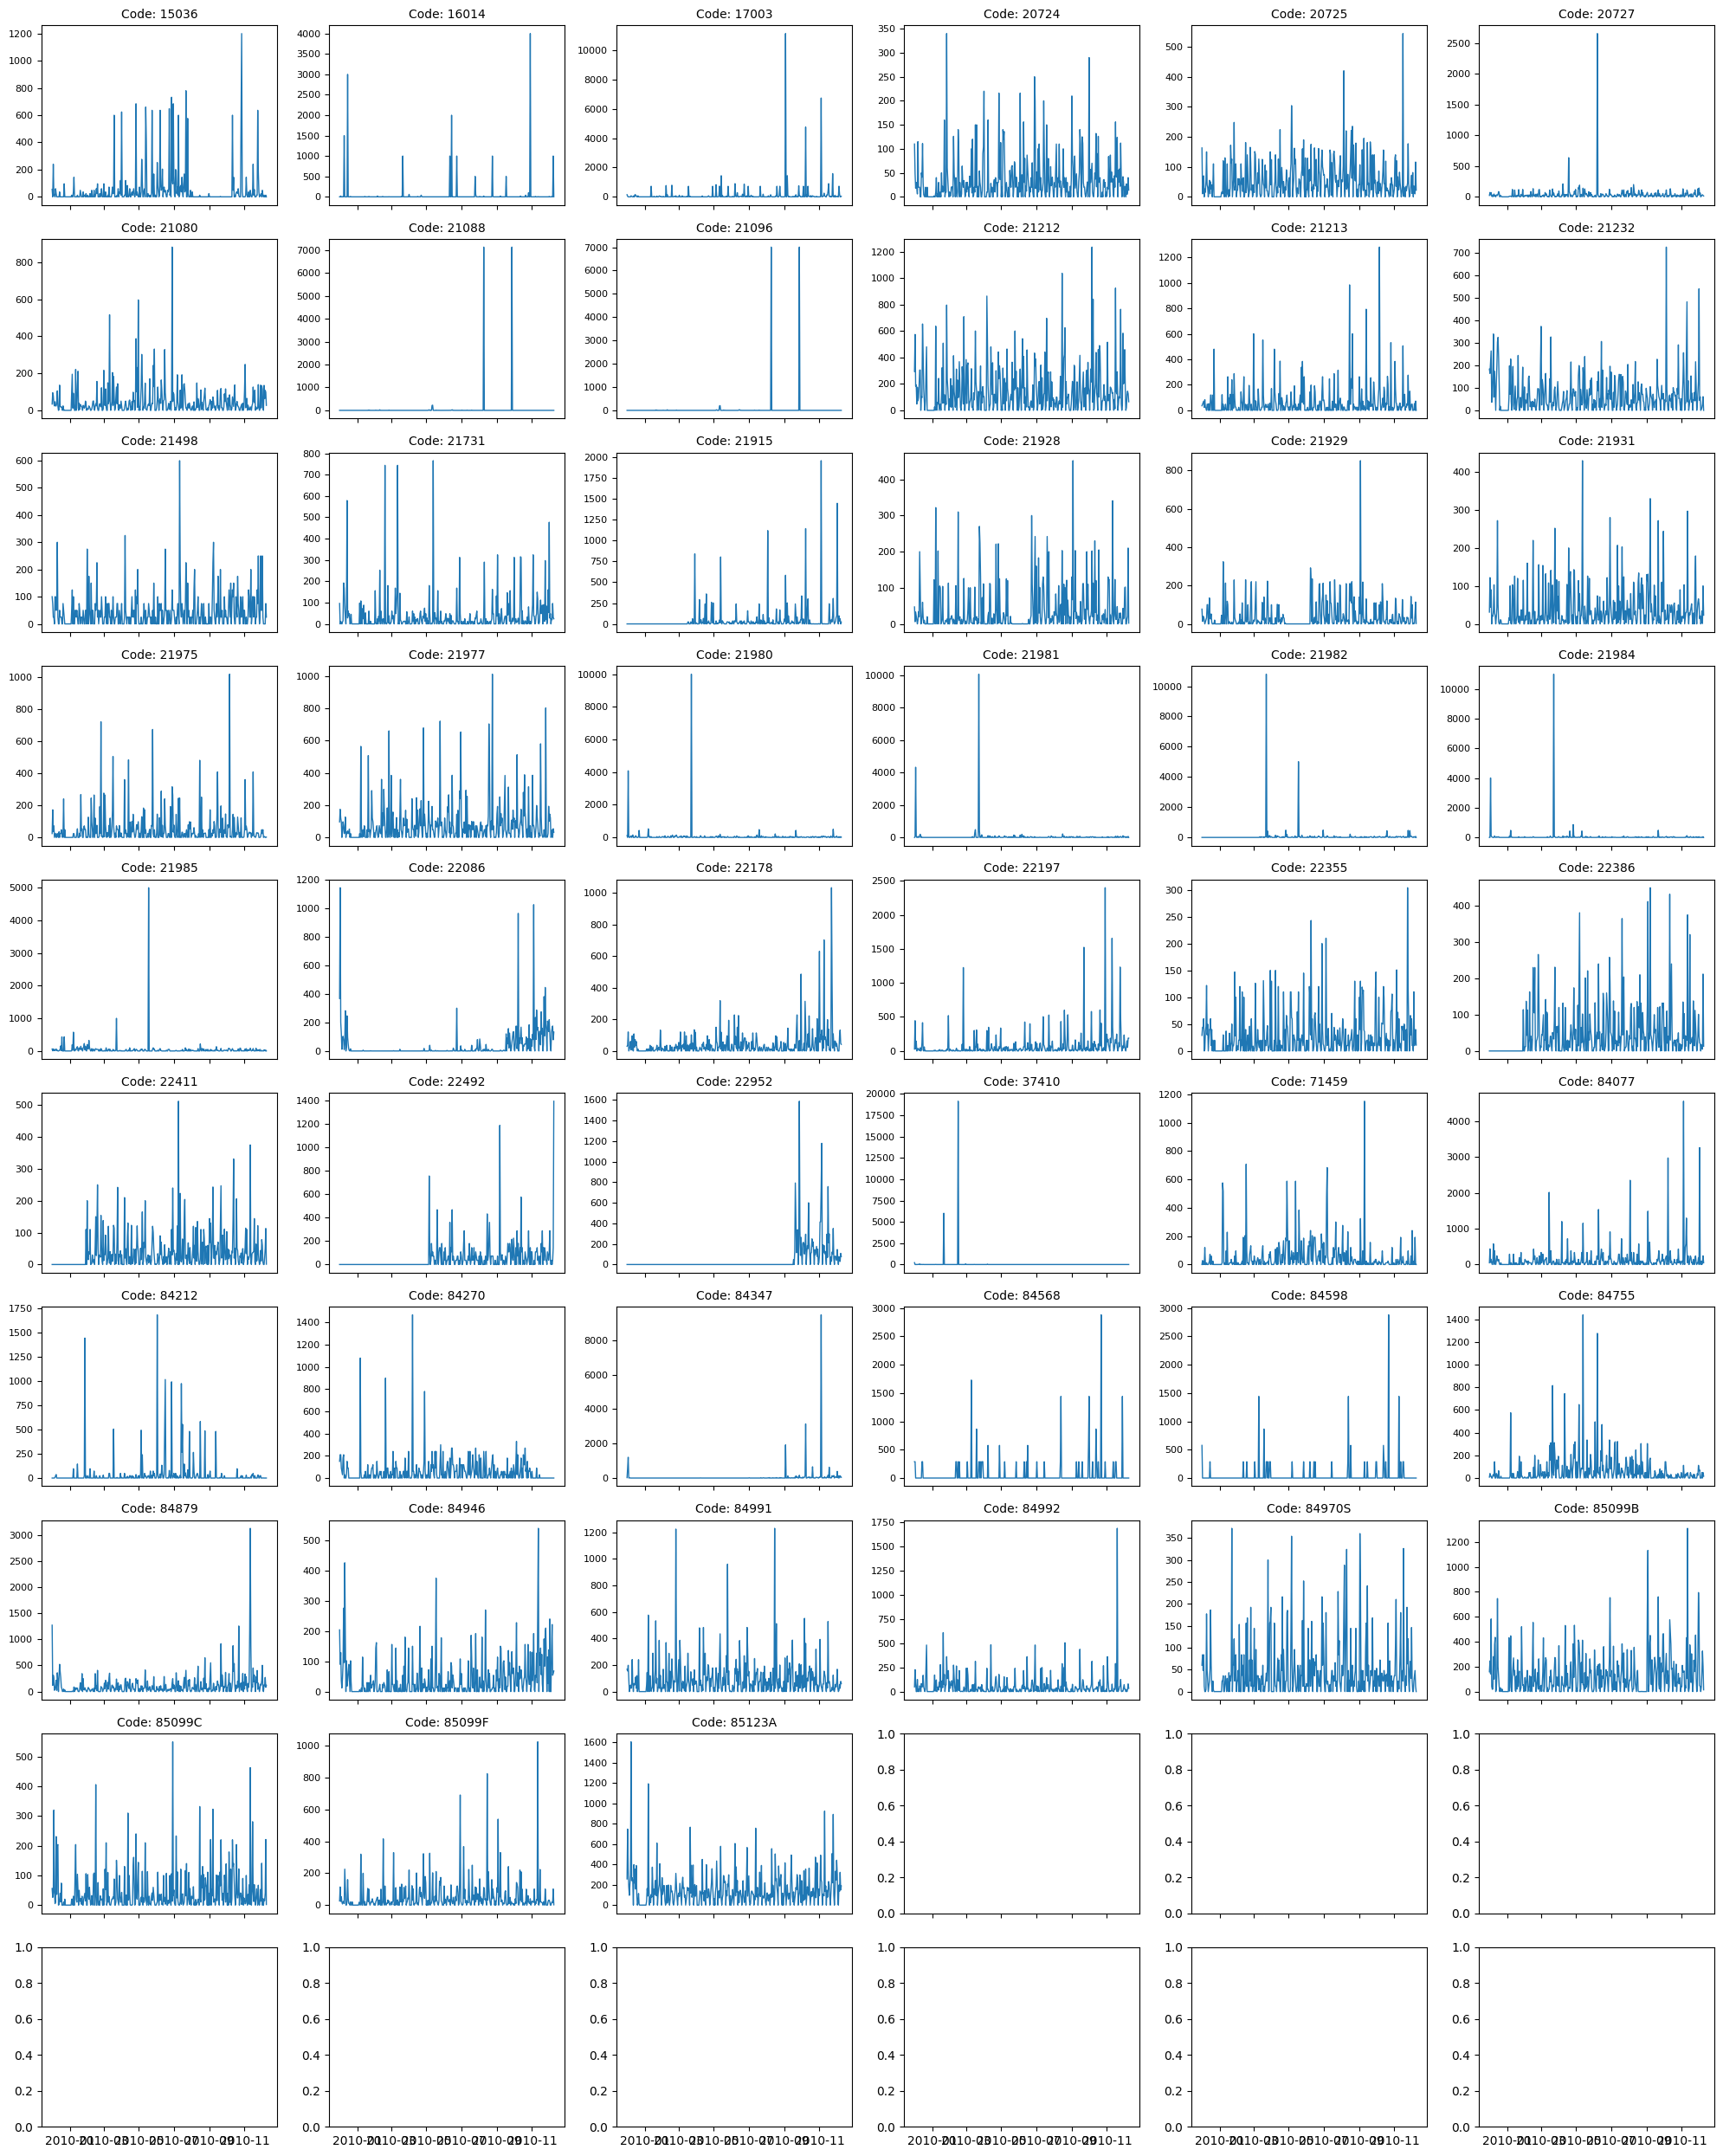

In [26]:
fig, axes = plt.subplots(nrows = 10, ncols = 6, figsize = (20, 25), sharex = True)
axes = axes.flatten()

top_50 = data_top_51_daily['StockCode'].unique()
for i, code in enumerate(top_50):
    subset = data_top_51_daily[data_top_51_daily['StockCode'] == code]

    axes[i].plot(subset['Date'], subset['Quantity'], color = 'tab:blue', linewidth = 1)
    axes[i].set_title(f'Code: {code}', fontsize = 10)

    axes[i].tick_params(axis = 'both', which = 'major', labelsize = 8)
    if i % 5 != 0:
        axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

So what do we get from the above visualization?

- Extreme Outliers: Code <p>
    we want to cap the values or use the IQR method to bring the spikes down to reasonable level, why? because leaving this spike could ruin the forecasting accuracy.
- Identify the "New" or "Discontinued" Items <p>
    We could sees some Products that are flat line at zero then they "wake up", Why this is concerning because when training model, we cannot use the "zero" period to predict the "active" period. So we want to filter this out, so this doesnt being bias to the model.
- Identify Seasonal Sleepers <p>
    What does this mean, they sell high at the very beginnning of the year, die off in the middle, and spike again at the end.
    This is `Seasonality`. And perfect for a model to get the clear "rhythm" to find.

In [ ]:
def clip_outliers(group):
    upper_limit = group['Quantity'].quantile(0.95)
    group['Quantity'] = group['Quantity'].clip(upper = upper_limit)
    return group

data_clip_51_daily = data_top_51_daily.groupby('StockCode').apply(clip_outliers).reset_index(drop=True)
data_clip_51_daily.head()

/tmp/ipykernel_32046/3376722958.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_clip_51_daily = data_top_51_daily.groupby('StockCode').apply(clip_outliers).reset_index(drop=True)


,Date,StockCode,Quantity
0,2009-12-01,15036,55.0
1,2009-12-02,15036,0.0
2,2009-12-03,15036,240.0
3,2009-12-04,15036,12.0
4,2009-12-05,15036,12.0


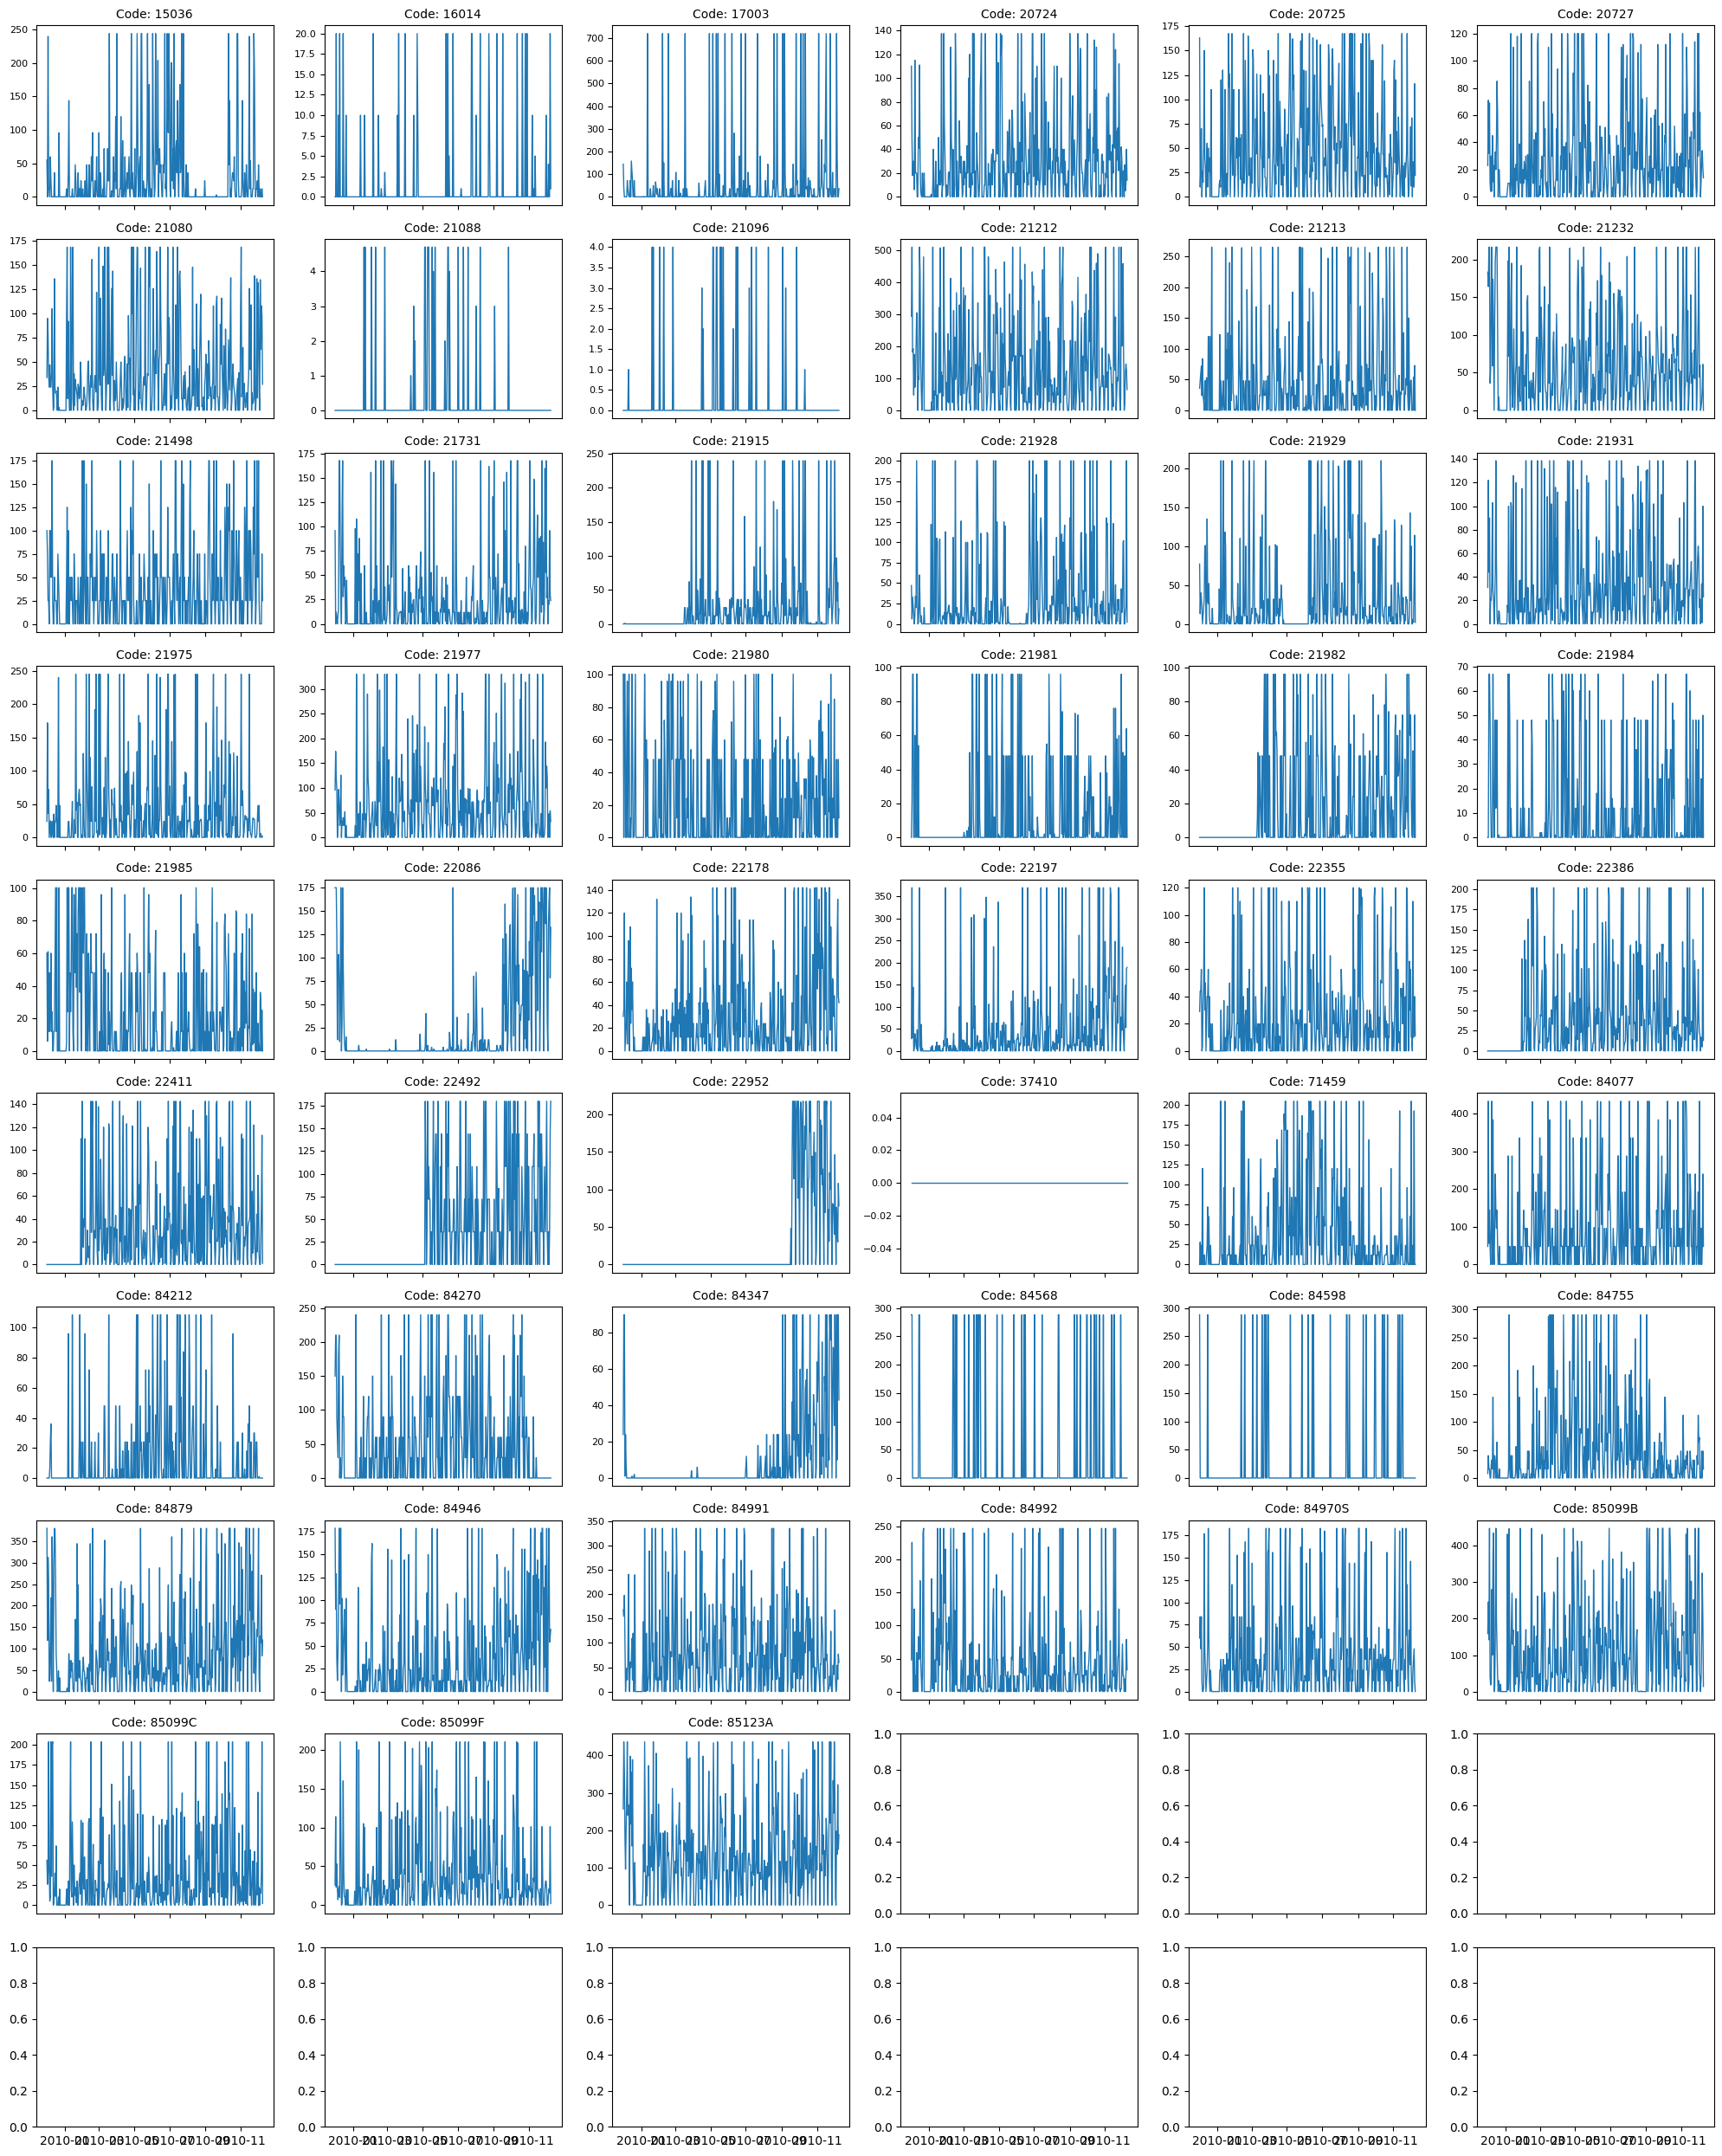

In [28]:
fig, axes = plt.subplots(nrows = 10, ncols = 6, figsize = (20, 25), sharex = True)
axes = axes.flatten()

top_51 = data_clip_51_daily['StockCode'].unique()
for i, code in enumerate(top_51):
    subset = data_clip_51_daily[data_clip_51_daily['StockCode'] == code]

    axes[i].plot(subset['Date'], subset['Quantity'], color = 'tab:blue', linewidth = 1)
    axes[i].set_title(f'Code: {code}', fontsize = 10)

    axes[i].tick_params(axis = 'both', which = 'major', labelsize = 8)
    if i % 5 != 0:
        axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

From above analysis after capping the outliers at the 95th percentile, we can see that we have removed the single giant spike so that the model wouldn't explode.

In [29]:
data_50_daily = data_clip_51_daily[data_clip_51_daily['StockCode'] != 37410]
data_50_daily['StockCode'].nunique()

50

In [30]:
data_50_daily.to_csv('../data/processed/demand_timeseries.csv')